In [33]:
from helpers.sporc import (
    SPORCDataset
)
from pprint import pprint
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd
import string
from nltk.corpus import stopwords
import hdbscan

In [34]:
sporc = SPORCDataset(local_data_dir="data", load_samples_only=True)

INFO:helpers.sporc.dataset:Loading SPORC dataset from local directory: data
INFO:helpers.sporc.dataset:Loading SPORC sample dataset only.
INFO:helpers.sporc.dataset:✓ All required files found
INFO:helpers.sporc.dataset:Loading all records from local files into memory...
INFO:helpers.sporc.dataset:Loading episode_data_sample...
INFO:helpers.sporc.dataset:Loading speaker_turn_data_sample...
INFO:helpers.sporc.dataset:✓ Loaded 210,000 total records from 2 files
INFO:helpers.sporc.dataset:✓ Local dataset loaded successfully in 16.81 seconds
INFO:helpers.sporc.dataset:✓ Dataset loaded successfully with 210000 total records
INFO:helpers.sporc.dataset:Processing dataset into Podcast and Episode objects...
INFO:helpers.sporc.dataset:Separating episode data from speaker turn data...


Loading episodes:   0%|          | 0/210000 [00:00<?, ?it/s]

INFO:helpers.sporc.dataset:✓ Separation completed in 0.21 seconds
INFO:helpers.sporc.dataset:  Episode records: 10,000, Speaker turn records: 200,000
INFO:helpers.sporc.dataset:Grouping episodes by podcast...
INFO:helpers.sporc.dataset:✓ Grouping completed in 0.06 seconds
INFO:helpers.sporc.dataset:  Episodes grouped into 1826 podcasts
INFO:helpers.sporc.dataset:Creating Podcast and Episode objects...
INFO:helpers.sporc.dataset:✓ Object creation completed in 1.53 seconds
INFO:helpers.sporc.dataset:Loading speaker turn data for episodes...
INFO:helpers.sporc.dataset:Loading turn data for 200,000 speaker turn records...
INFO:helpers.sporc.dataset:Grouping turns by episode URL...
INFO:helpers.sporc.dataset:✓ Turn grouping completed in 0.29 seconds
INFO:helpers.sporc.dataset:  Turns grouped into 1,033 episodes
INFO:helpers.sporc.dataset:Loading turns for each episode...
INFO:helpers.sporc.dataset:✓ Turn loading completed in 2.56 seconds
INFO:helpers.sporc.dataset:  Episodes with turns: 1,0

In [59]:
episodes = sporc.get_all_episodes()

interruptions = []                  # all interruption texts 
interruptions_per_episode = []      # count per episode

for episode in episodes:
    turns = episode.get_all_turns()
    count = 0   # interruption count for this episode
    
    for i in range(len(turns)-1):
        if (turns[i].end_time > turns[i+1].start_time and
            turns[i].speaker != turns[i+1].speaker):
            
            interruptions.append(turns[i+1].text)
            count += 1

    interruptions_per_episode.append(count)


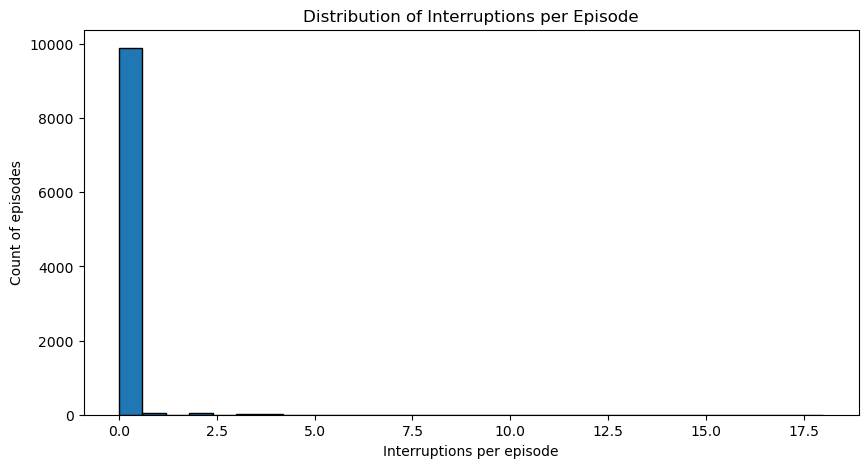

In [58]:
plt.figure(figsize=(10, 5))
plt.hist(interruptions_per_episode, bins=30, edgecolor='black')

plt.title("Distribution of Interruptions per Episode")
plt.xlabel("Interruptions per episode")
plt.ylabel("Count of episodes")

plt.show()

In [52]:
#preprocessing pipeline
#remove outliers with isolation forests e.g?

stop_words = set(stopwords.words("english"))

def starts_with_upper(s):
    if not s:          # empty string
        return False
    if s[0].isspace(): # skip whitespace
        return starts_with_upper(s[1:])
    return s[0].isupper()

def is_meaningless_single_word(s):

    text = s.strip().lower()
    text = text.strip(string.punctuation)
    words = text.split()
    if len(words) != 1:  #multi-word → potentially meaningful
        return False

    w = words[0]

    # too short (1-2 chars)
    if len(w) <= 2:
        return True

    # stopwords → usually not standalone interruptions
    if w in stop_words:
        return True

    # remove nonsensical words (e.g. "'re", "n't")
    if not w.isalpha():
        return True

    # otherwise it's meaningful ("wait", "stop", "listen")
    return False

def keep_interruption(s):
    # remove pure punctuation
    if all(ch in string.punctuation or ch.isspace() for ch in s):
        return False
    
    # remove meaningless one-word fragments
    if is_meaningless_single_word(s):
        return False
    
    if not starts_with_upper(s): #starts with lowercase letter
        return False

    return True

clean_interruptions = [s for s in interruptions if keep_interruption(s)]
print(len(clean_interruptions), "cleaned interruptions out of", len(interruptions))
pprint(clean_interruptions[1]) 

74 cleaned interruptions out of 215
(" Today, we're going to talk about a subject that is clouded in uncertainty "
 'right now, the future. Thanks for joining me on 5G Talent Talk. This is '
 'Kerry Charles, and I am thrilled to have with me today, Adam Zuckerman. He '
 'is a subject matter expert focused on the impact and implementation of '
 "future facing technologies and the fourth industrial revolution. He's an "
 'entrepreneur, an attorney, and MBA. He currently leads international '
 "development at the Energy Impact Center in Washington, D.C. It's a research "
 "institute focused on drastically reducing the cost of nuclear energy. He's a "
 '2018 fellow and spent time in China studying blockchain, AI, and the future '
 "of work, and he's an adjunct professor teaching innovation strategy at the "
 'University of Maryland. Adam, thank you so much for being on the show today. '
 "It's wonderful to be here. So, Adam, let's talk a little bit about the "
 'fourth industrial revolutio

In [37]:
#sentence embeddings
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
embeddings = model.encode(clean_interruptions)
print(embeddings.shape)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-mpnet-base-v2


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

(74, 768)


In [38]:
# Step 1: Dimensionality reduction
pca = PCA(n_components=20, random_state=42)
reduced_embeddings = pca.fit_transform(embeddings)

# Step 2: Compute silhouette scores on reduced embeddings
def evaluate_k_range(X, k_min=3, k_max=15):
    scores = {}
    for k in range(k_min, k_max + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores[k] = score
        print(f"k={k} → silhouette={score:.4f}")
    return scores

scores = evaluate_k_range(reduced_embeddings)

# Step 3: Pick k with highest silhouette score and cluster
k = max(scores, key=scores.get)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(reduced_embeddings)

# Step 4: Print cluster assignments
for text, label in zip(clean_interruptions, labels):
    print(f"[Cluster {label}] {text}")


k=3 → silhouette=0.0970
k=4 → silhouette=0.1158
k=5 → silhouette=0.1089
k=6 → silhouette=0.1190
k=7 → silhouette=0.1017
k=8 → silhouette=0.1262
k=9 → silhouette=0.1506
k=10 → silhouette=0.1594
k=11 → silhouette=0.1531
k=12 → silhouette=0.1621
k=13 → silhouette=0.1626
k=14 → silhouette=0.1682
k=15 → silhouette=0.1661
[Cluster 3]  It's always been the problem that people are sleeping. So I want you to turn with me to Psalm 81. And I want to read some verses that are phenomenal. Because not everything that happens is God's will. Sometimes people say, "Oh, this terrible thing happened. It must be God's will." That is such ridiculous thinkology. Let me read something to you about his Old Testament people. Psalm 81, look at it with me. Verse 13, God cries. He actually is really, really passionate here. He says, "Oh, that my people had hearkened unto me." And Israel had walked in my ways. You know, the word hearkened the root word is here. You know, we need to hear what the Spirit would say. 

In [39]:
#interpret cluster centers
cluster_centers = kmeans.cluster_centers_
for c in range(k):
    print(f"\nCluster {c} examples:")
    idxs = np.where(labels == c)[0][:2] # show 2 examples per cluster
    for i in idxs:
        print("  ", clean_interruptions[i])


Cluster 0 examples:
    I mean, for the clout to say that, you can check my IMDB. I got the credit card. So just to use this. - This is the only one that I want published. - Right, this is it right here. That's all I need. Mike
    Every look breaking news, everybody in history that has ever died is a bust. If you die, you are busted. I don't know what else to tell you. Yeah, Gandhi, you were busted. Am I OK? You were busted. We already knew Hitler is a busted. Actually, we now know Gandhi was a busted. Busted busters. Everybody everybody's ever died is a busted. It's great to me. Oh, that's great to me. That's the best buster and and let's hope he never find ice. Yeah, you know, maybe I should have been pretty creepy. But let's hope he lives a long life. Yeah, you know. So yeah, listen, the violence is here. But, you know, this is a violent album. And if you don't know that by now, I don't know why you're still listening. I have a seven plus. You don't know that by now. Oh, God. Yeah

In [43]:
#t-SNE visualization of clusters
def plot_clustering(embeddings, labels, dims=2, texts=None, perplexity=30, random_state=42):
    """
    Visualizes sentence clusters using t-SNE in 2D or 3D.

    Parameters:
    - embeddings: numpy array of shape (n_samples, n_features)
    - labels: list or array of cluster labels
    - dims: 2 or 3 (number of t-SNE output dimensions)
    - texts: optional list of sentences (used only for 3D tooltips)
    - perplexity: t-SNE perplexity
    - random_state: random seed for reproducibility
    """

    if dims not in [2, 3]:
        raise ValueError("dims must be 2 or 3.")

    tsne = TSNE(
        n_components=dims,
        perplexity=perplexity,
        random_state=random_state
    )

    projections = tsne.fit_transform(embeddings)

    # ---------------------- 2D PLOT ----------------------
    if dims == 2:
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(
            projections[:, 0],
            projections[:, 1],
            c=labels,
            s=50,
            alpha=0.8
        )
        plt.title("t-SNE Clustering (2D)")
        plt.xlabel("TSNE-1")
        plt.ylabel("TSNE-2")
        plt.show()

    # ---------------------- 3D PLOT ----------------------
    else:
        if texts is None:
            texts = [""] * len(labels)

        df_plot = pd.DataFrame({
            "x": projections[:, 0],
            "y": projections[:, 1],
            "z": projections[:, 2],
            "cluster": labels,
            "text": texts
        })

        fig = px.scatter_3d(
            df_plot, 
            x='x', y='y', z='z',
            color='cluster',
            hover_name='text',
            labels={'color': 'cluster'}
        )
        fig.update_traces(marker_size=4)
        fig.update_layout(title="t-SNE Clustering (3D)")
        fig.show()

In [47]:
plot_clustering(reduced_embeddings, labels, dims=3, texts=clean_interruptions)

In [50]:
# HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=3, metric='euclidean')
dbscan_labels = clusterer.fit_predict(reduced_embeddings)

# Step 3: Print clusters
for text, label in zip(clean_interruptions, dbscan_labels):
    print(f"[Cluster {label}] {text}")

plot_clustering(reduced_embeddings, dbscan_labels, dims=3, texts=clean_interruptions)

/Users/mikkel/miniconda3/envs/exam/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/mikkel/miniconda3/envs/exam/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



[Cluster -1]  It's always been the problem that people are sleeping. So I want you to turn with me to Psalm 81. And I want to read some verses that are phenomenal. Because not everything that happens is God's will. Sometimes people say, "Oh, this terrible thing happened. It must be God's will." That is such ridiculous thinkology. Let me read something to you about his Old Testament people. Psalm 81, look at it with me. Verse 13, God cries. He actually is really, really passionate here. He says, "Oh, that my people had hearkened unto me." And Israel had walked in my ways. You know, the word hearkened the root word is here. You know, we need to hear what the Spirit would say. We need to be awakened. And so they didn't hear. And God says, "Oh, that my people would have hearkened unto me." And Israel had walked in my ways. And look what he says, "I should soon have subdued their enemies and turned against their adversaries." Verse 15, "The haters of the Lord should have submitted themselve